# Appendix: Brief Euclid

Source orientation: Hartshorne, *Geometry: Euclid and Beyond*, Appendix "Brief Euclid", printed pages 481-486 (PDF pages 493-498). The PDF pages were used only for orientation. No appendix prose, proposition text, screenshots, crops, or original figures are reproduced here.

## Question

How can six pages of Euclid references become a working map for the course rather than a list of theorem names?

## Chapter Goal

Turn the appendix into a compact reference notebook: Books I-XIII become a dependency graph, the major construction/proportion/number/solid themes become generated tables and maps, and selected Euclid proposition tags become modern checkpoints for diagrams, symbolic identities, graph dependencies, and mesh counts.

The source span lists definitions, postulates, common notions, and selected proposition tags from Books I-VI and X-XIII. Books VII-IX are not itemized in this appendix span, but this notebook includes them in the whole-Elements dependency map because the number-theory books are the natural arithmetic bridge into Book X.


## Computational Translation Guide

| Euclid reference object | Computational representation | What the notebook checks |
| --- | --- | --- |
| Definition, postulate, common notion | model predicate or permitted operation | incidence, equality, extension, circle, and order assumptions are explicit |
| Proposition tag | named checkpoint row, not copied text | each tag is attached to an inspectable invariant |
| Construction result | algorithm with a witness point, line, circle, or polygon | constructed object exists and satisfies equal-length, angle, or incidence data |
| Area and algebraic geometry | exact polynomial or determinant identity | symbolic residue is zero |
| Ratio and similarity | equality of positive ratios, scale factors, or products | ratios match and area scales quadratically |
| Number and incommensurability | integer/radical obstruction or descent data | rational approximants do not make the obstruction vanish |
| Solid geometry | mesh counts, vertex data, and angle budget | Euler characteristic and finite regular-solid candidates are recovered |

## Route

1. Build a source-aware book table for Books I-XIII.
2. Generate a dependency map showing which books feed later checkpoints.
3. Generate a theme flow from Euclid books to modern course uses.
4. Draw a compact visual gallery for construction, proportion, number, and solid-geometry checkpoints.
5. Run an applied lab that computes prerequisite closures for a target checkpoint.
6. Finish with final_sanity: artifact existence, graph invariants, symbolic identities, and geometric checks.


## Standalone Reading Guide

This appendix notebook is a compact map of Euclid's books as they are reused by the course, not a reproduction of the printed appendix. The aim is to help a reader see where construction, proportion, number theory, irrational magnitudes, and solid geometry enter the later chapters. Each book is represented by a generated theme label, a dependency position, and a modern checkpoint rather than by copied proposition text.

The roadmap figure shows the large-scale movement from plane construction to proportion, arithmetic, and solids. The construction gallery picks a few representative geometric acts so the appendix remains visual and inspectable. The Sankey-style flow then shows how themes migrate into the notebooks: construction certificates feed Chapter 1, axiomatic dependencies feed Chapter 2, proportion and arithmetic feed the field and segment chapters, and solid geometry feeds the polyhedra chapter. The applied lab computes prerequisite closures so the appendix behaves like a navigable dependency tool.

Use the tables as an index into the course, not as a substitute for Euclid. They are deliberately generated artifacts with checks for graph consistency, theme coverage, exact numeric identities, and file integrity. That keeps the appendix original, executable, and useful without copying the source reference.


Because the appendix is short, the notebook deliberately emphasizes navigation. A reader can use it before a chapter to see which Euclidean themes are about to be reused, or after a chapter to locate the older construction or proposition family behind a modern algebraic or topological reformulation. The generated closure lab makes that navigation executable.


The appendix therefore acts like a compact dependency dashboard. It tells the reader which inherited Euclidean habit is being tested: constructing an object, comparing ratios, organizing number, or measuring a solid. The checks make sure those theme links remain internally consistent.
 It is a map, not a paraphrase.

In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
from matplotlib.patches import Arc, Circle, FancyArrowPatch, Polygon
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find the Euclid and Beyond book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifact, display_artifact, save_json, save_matplotlib, save_plotly_html

UNIT = "appendix-brief-euclid"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts"
UNIT_ARTIFACT_ROOT = ARTIFACT_ROOT / UNIT
FIGURES = UNIT_ARTIFACT_ROOT / "figures"
INTERACTIVE = UNIT_ARTIFACT_ROOT / "interactive"
TABLES = UNIT_ARTIFACT_ROOT / "tables"
CHECKS = UNIT_ARTIFACT_ROOT / "checks"
for folder in [FIGURES, INTERACTIVE, TABLES, CHECKS]:
    folder.mkdir(parents=True, exist_ok=True)

artifact_records = []


def record_artifact(path, concept, min_bytes=512):
    path = assert_artifact(path, min_bytes=min_bytes)
    if not path.resolve().is_relative_to(UNIT_ARTIFACT_ROOT.resolve()):
        raise AssertionError(f"Artifact escaped appendix subtree: {path}")
    record = {
        "concept": concept,
        "path": path.relative_to(BOOK_ROOT).as_posix(),
        "bytes": path.stat().st_size,
    }
    artifact_records.append(record)
    return path


def roman(n):
    return ["I", "II", "III", "IV", "V", "VI", "VII", "VIII", "IX", "X", "XI", "XII", "XIII"][n - 1]


theme_colors = {
    "foundations": "#2b6cb0",
    "construction": "#2f855a",
    "circle": "#319795",
    "proportion": "#805ad5",
    "number": "#b7791f",
    "solid": "#c53030",
}

book_rows = [
    {"book": "I", "book_num": 1, "primary_theme": "foundations", "source_selected": True, "source_role": "definitions, postulates, common notions, planar constructions, parallels, area, metric tests", "sample_tags": "defs; postulates; common notions; I.1; I.9-12; I.27-32; I.35-48", "course_checkpoint": "axiom audit, straightedge-compass moves, parallel-postulate and Pythagorean checks"},
    {"book": "II", "book_num": 2, "primary_theme": "construction", "source_selected": True, "source_role": "geometric algebra through rectangles and squares", "sample_tags": "II.1; II.4-6; II.11; II.14", "course_checkpoint": "segment arithmetic and exact polynomial identities"},
    {"book": "III", "book_num": 3, "primary_theme": "circle", "source_selected": True, "source_role": "circle centers, tangents, chords, cyclic angles, secants", "sample_tags": "III.1-2; III.16-22; III.31-37", "course_checkpoint": "circle predicates, tangent perpendicularity, inversion-era power checks"},
    {"book": "IV", "book_num": 4, "primary_theme": "construction", "source_selected": True, "source_role": "inscribed and circumscribed figures, regular polygons", "sample_tags": "IV.1-5; IV.10-12; IV.15-16", "course_checkpoint": "polygon construction and regular-pentagon tests"},
    {"book": "V", "book_num": 5, "primary_theme": "proportion", "source_selected": True, "source_role": "general theory of ratio for magnitudes", "sample_tags": "V.def.4-5", "course_checkpoint": "ordered magnitude comparison and Eudoxus-style ratio logic"},
    {"book": "VI", "book_num": 6, "primary_theme": "proportion", "source_selected": True, "source_role": "similar triangles, proportional cuts, mean proportional, similar figures", "sample_tags": "VI.1-6; VI.8; VI.12-13; VI.16; VI.30-31", "course_checkpoint": "similarity, coordinates, and proportional-area checks"},
    {"book": "VII", "book_num": 7, "primary_theme": "number", "source_selected": False, "source_role": "not itemized in the appendix span; whole-book arithmetic bridge", "sample_tags": "number theory bridge", "course_checkpoint": "integer divisibility and Euclidean algorithm context"},
    {"book": "VIII", "book_num": 8, "primary_theme": "number", "source_selected": False, "source_role": "not itemized in the appendix span; whole-book arithmetic bridge", "sample_tags": "continued proportion bridge", "course_checkpoint": "powers, ratios, and discrete proportional structure"},
    {"book": "IX", "book_num": 9, "primary_theme": "number", "source_selected": False, "source_role": "not itemized in the appendix span; whole-book arithmetic bridge", "sample_tags": "number theory bridge", "course_checkpoint": "arithmetic obstruction and finite descent context"},
    {"book": "X", "book_num": 10, "primary_theme": "number", "source_selected": True, "source_role": "exhaustion-style size lemma and incommensurability", "sample_tags": "X.1; X.117", "course_checkpoint": "constructibility obstructions and radical degree checks"},
    {"book": "XI", "book_num": 11, "primary_theme": "solid", "source_selected": True, "source_role": "solid definitions, solid angles, parallelepipeds", "sample_tags": "XI.def.25-28; XI.21; XI.28-31", "course_checkpoint": "polyhedron vocabulary, volume equality, and mesh diagnostics"},
    {"book": "XII", "book_num": 12, "primary_theme": "solid", "source_selected": True, "source_role": "exhaustion and volume comparison", "sample_tags": "XII.2-3; XII.5; XII.7", "course_checkpoint": "area and volume ratios, pyramid/prism decomposition"},
    {"book": "XIII", "book_num": 13, "primary_theme": "solid", "source_selected": True, "source_role": "regular pentagon and the five regular solids in spheres", "sample_tags": "XIII.7; XIII.10; XIII.13-18", "course_checkpoint": "Platonic-solid classification and Euler/angle-defect sanity checks"},
]

book_df = pd.DataFrame(book_rows)
book_table_path = TABLES / "euclid-book-theme-index.csv"
book_df.to_csv(book_table_path, index=False)
record_artifact(book_table_path, "Book theme index table", min_bytes=512)
book_df[["book", "primary_theme", "source_selected", "sample_tags", "course_checkpoint"]]


,book,primary_theme,source_selected,sample_tags,course_checkpoint
0,I,foundations,True,defs; postulates; common notions; I.1; I.9-12;...,"axiom audit, straightedge-compass moves, paral..."
1,II,construction,True,II.1; II.4-6; II.11; II.14,segment arithmetic and exact polynomial identi...
2,III,circle,True,III.1-2; III.16-22; III.31-37,"circle predicates, tangent perpendicularity, i..."
3,IV,construction,True,IV.1-5; IV.10-12; IV.15-16,polygon construction and regular-pentagon tests
4,V,proportion,True,V.def.4-5,ordered magnitude comparison and Eudoxus-style...
5,VI,proportion,True,VI.1-6; VI.8; VI.12-13; VI.16; VI.30-31,"similarity, coordinates, and proportional-area..."
6,VII,number,False,number theory bridge,integer divisibility and Euclidean algorithm c...
7,VIII,number,False,continued proportion bridge,"powers, ratios, and discrete proportional stru..."
8,IX,number,False,number theory bridge,arithmetic obstruction and finite descent context
9,X,number,True,X.1; X.117,constructibility obstructions and radical degr...


## Books I-XIII As A Dependency Map

The appendix is selective: it emphasizes the proposition tags that Hartshorne cites most often. The map below treats every book as a node so the omissions are visible too. Solid outlines mark books directly itemized in the appendix span; faded dashed outlines mark Books VII-IX, which are needed as arithmetic context but are not listed in these six pages.

Inspection target: follow any arrow into a later book and ask what kind of data moved forward. For example, Book V ratio language feeds Book VI similarity and Book X incommensurability; Book XI solid vocabulary feeds the volume comparisons and regular-solid classification in Books XII-XIII.


In [2]:
dependency_edges = [
    ("I", "II", "area algebra"), ("I", "III", "circle predicates"), ("I", "IV", "constructions"), ("III", "IV", "inscribed figures"),
    ("I", "V", "magnitudes"), ("I", "VI", "triangles"), ("V", "VI", "ratio theory"),
    ("VII", "VIII", "proportional numbers"), ("VII", "IX", "integer arithmetic"), ("VIII", "IX", "number structure"),
    ("V", "X", "magnitude comparison"), ("VI", "X", "mean proportionals"), ("VII", "X", "commensurability"), ("VIII", "X", "ratio patterns"), ("IX", "X", "finite descent"),
    ("I", "XI", "plane foundations"), ("VI", "XI", "similarity and ratio"), ("XI", "XII", "solid vocabulary"), ("V", "XII", "exhaustion ratios"),
    ("X", "XIII", "pentagon arithmetic"), ("XI", "XIII", "regular solids"), ("XII", "XIII", "spheres and volumes"), ("IV", "XIII", "regular pentagon"),
]

G = nx.DiGraph()
for row in book_rows:
    G.add_node(row["book"], **row)
for source, target, label in dependency_edges:
    G.add_edge(source, target, label=label)

pos = {"I": (0, 0.2), "II": (1.2, 1.25), "III": (1.2, 0.3), "IV": (2.35, 0.8), "V": (1.2, -1.05), "VI": (2.35, -0.55), "VII": (2.25, -1.65), "VIII": (3.45, -1.65), "IX": (4.65, -1.65), "X": (5.75, -0.9), "XI": (4.1, 0.65), "XII": (5.35, 0.65), "XIII": (6.6, 0.15)}

fig, ax = plt.subplots(figsize=(13.5, 7.2))
ax.set_facecolor("#fbfbf7")
for source, target, label in dependency_edges:
    sx, sy = pos[source]
    tx, ty = pos[target]
    ax.add_patch(FancyArrowPatch((sx, sy), (tx, ty), arrowstyle="-|>", mutation_scale=12, linewidth=1.3, color="#4a5568", alpha=0.72, shrinkA=22, shrinkB=22, connectionstyle="arc3,rad=0.08"))

for row in book_rows:
    x, y = pos[row["book"]]
    color = theme_colors[row["primary_theme"]]
    alpha = 1.0 if row["source_selected"] else 0.32
    line_style = "-" if row["source_selected"] else "--"
    ax.add_patch(Circle((x, y), 0.31, facecolor=color, edgecolor="#111827", linewidth=1.7, linestyle=line_style, alpha=alpha))
    ax.text(x, y + 0.04, row["book"], ha="center", va="center", fontsize=13, weight="bold", color="white" if row["source_selected"] else "#1f2937")
    ax.text(x, y - 0.48, row["primary_theme"], ha="center", va="top", fontsize=8.5, color="#1f2937")

legend_y = 1.82
for i, (theme, color) in enumerate(theme_colors.items()):
    x = 0.15 + i * 1.13
    ax.scatter([x], [legend_y], s=170, color=color, edgecolor="#111827")
    ax.text(x + 0.16, legend_y, theme, va="center", fontsize=9)
ax.text(0.15, -2.25, "Dashed faded nodes: Books VII-IX are included as arithmetic context, though this appendix span does not itemize them.", fontsize=10, color="#4a5568")
ax.set_title("Brief Euclid as a dependency map of Books I-XIII", fontsize=16, weight="bold", loc="left")
ax.set_xlim(-0.45, 7.15)
ax.set_ylim(-2.55, 2.05)
ax.axis("off")
roadmap_path = save_matplotlib(fig, UNIT, "figures", "euclid-book-roadmap.png", root=ARTIFACT_ROOT, dpi=180)
plt.close(fig)
record_artifact(roadmap_path, "Books I-XIII dependency map", min_bytes=20_000)

book_graph_checks = {"node_count": G.number_of_nodes(), "edge_count": G.number_of_edges(), "is_dag": nx.is_directed_acyclic_graph(G), "books": list(book_df["book"]), "source_selected_books": book_df.loc[book_df["source_selected"], "book"].tolist(), "appendix_silent_arithmetic_books": book_df.loc[~book_df["source_selected"], "book"].tolist(), "themes": sorted(book_df["primary_theme"].unique())}
assert book_graph_checks["node_count"] == 13
assert book_graph_checks["is_dag"]
book_graph_checks


{'node_count': 13,
 'edge_count': 23,
 'is_dag': True,
 'books': ['I',
  'II',
  'III',
  'IV',
  'V',
  'VI',
  'VII',
  'VIII',
  'IX',
  'X',
  'XI',
  'XII',
  'XIII'],
 'source_selected_books': ['I',
  'II',
  'III',
  'IV',
  'V',
  'VI',
  'X',
  'XI',
  'XII',
  'XIII'],
 'appendix_silent_arithmetic_books': ['VII', 'VIII', 'IX'],
 'themes': ['circle',
  'construction',
  'foundations',
  'number',
  'proportion',
  'solid']}

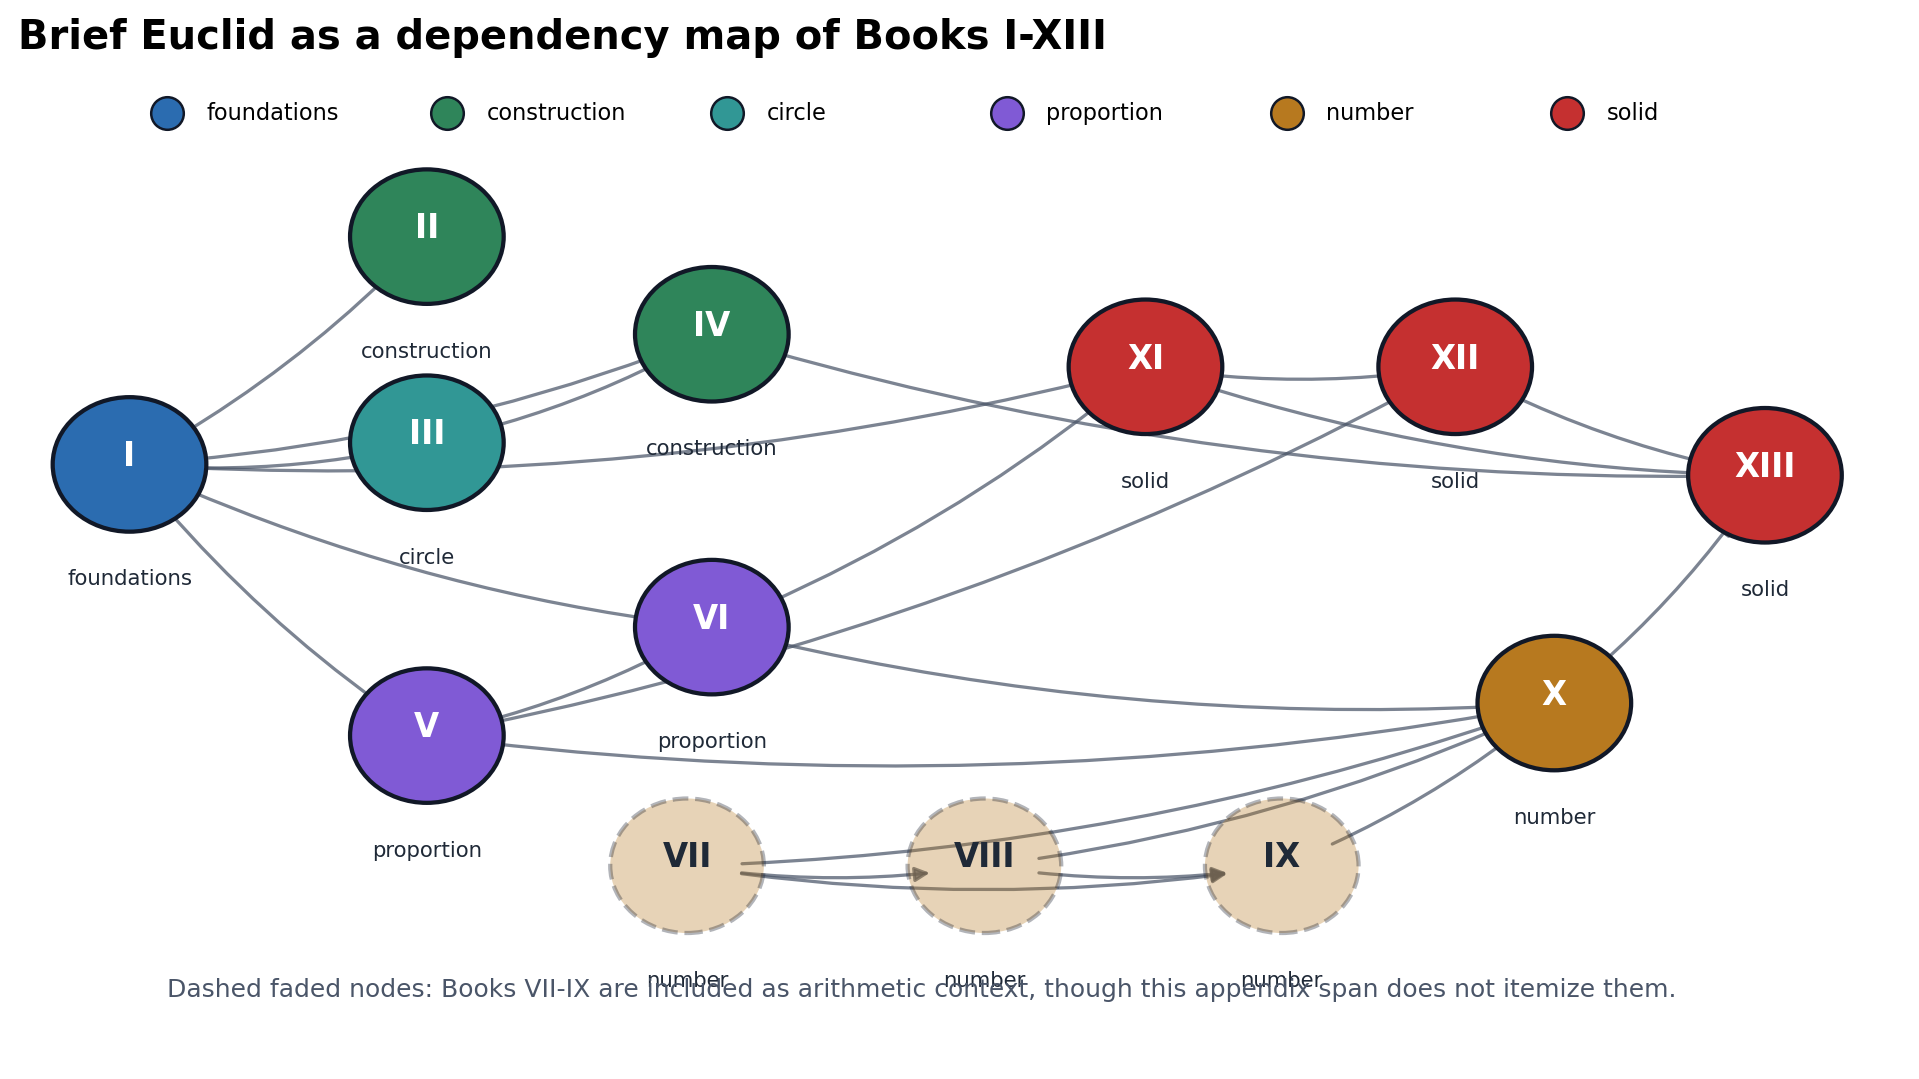

In [3]:
display_artifact(roadmap_path, width=980)


## Theme Route: From Euclid Tags To Course Checkpoints

The next table compresses the appendix into reusable checkpoint clusters. The clusters are intentionally modernized: a proposition tag becomes something a notebook can test, such as a zero symbolic residue, a ratio equality, a graph dependency, or a mesh count. This is why the appendix remains useful after the course moves from synthetic proofs to coordinates, fields, hyperbolic models, and polyhedra.


In [4]:
checkpoint_rows = [
    {"source_cluster": "Book I definitions, postulates, common notions", "theme": "foundations", "modern_checkpoint": "model predicates for point, line, circle, equality, extension, and comparison", "course_reuse": "Ch. 1-3 axiom and model audits", "check_type": "incidence/equality assumptions"},
    {"source_cluster": "I.1, I.9-I.12, I.46", "theme": "construction", "modern_checkpoint": "construct witness objects and verify equal lengths, bisection, perpendicularity, or square sides", "course_reuse": "Ch. 1 and Ch. 6 straightedge-compass construction tests", "check_type": "distance and angle residuals"},
    {"source_cluster": "I.27-I.32", "theme": "foundations", "modern_checkpoint": "compare Euclidean parallel consequences with neutral and hyperbolic behavior", "course_reuse": "Ch. 2 and Ch. 7 parallel-postulate checkpoints", "check_type": "angle sum and parallel predicate"},
    {"source_cluster": "I.35-I.48", "theme": "construction", "modern_checkpoint": "translate area comparisons and the Pythagorean theorem into exact identities", "course_reuse": "Ch. 4-5 segment arithmetic and area", "check_type": "polynomial and area residuals"},
    {"source_cluster": "Book II selected area algebra", "theme": "construction", "modern_checkpoint": "turn rectangle-and-square statements into algebraic expansions", "course_reuse": "Ch. 4 coordinates and segment operations", "check_type": "SymPy identity"},
    {"source_cluster": "Book III circle and tangent tags", "theme": "circle", "modern_checkpoint": "test center, tangent, chord, angle, and secant power relations", "course_reuse": "Ch. 1 circle constructions and Ch. 7 inversion", "check_type": "orthogonality and product equality"},
    {"source_cluster": "Book IV regular polygon tags", "theme": "construction", "modern_checkpoint": "regular polygon construction is a field/angle checkpoint", "course_reuse": "Ch. 6 constructibility", "check_type": "side length and symmetry residuals"},
    {"source_cluster": "Book V-VI ratio and similarity tags", "theme": "proportion", "modern_checkpoint": "ratios, similar triangles, fourth/mean proportionals, and similar-figure area scaling", "course_reuse": "Ch. 4 segment arithmetic and Ch. 6 field extensions", "check_type": "ratio/product equality"},
    {"source_cluster": "Books VII-IX arithmetic bridge", "theme": "number", "modern_checkpoint": "integer arithmetic supplies the language for obstruction and descent", "course_reuse": "Ch. 6 constructibility obstructions", "check_type": "integer/radical obstruction"},
    {"source_cluster": "Book X size and incommensurability tags", "theme": "number", "modern_checkpoint": "detect a radical relation that no rational square can satisfy exactly", "course_reuse": "Ch. 3 fields and Ch. 6 extensions", "check_type": "minimal polynomial residual"},
    {"source_cluster": "Book XI-XII solid and volume tags", "theme": "solid", "modern_checkpoint": "represent solids by counts, decompositions, and volume-ratio invariants", "course_reuse": "Ch. 5 volume and Ch. 8 polyhedra", "check_type": "Euler and volume ratios"},
    {"source_cluster": "Book XIII regular-solid tags", "theme": "solid", "modern_checkpoint": "classify regular convex solids by finite angle-budget candidates", "course_reuse": "Ch. 8 regular solids", "check_type": "Euler characteristic and angle defect"},
]
checkpoint_df = pd.DataFrame(checkpoint_rows)
checkpoint_path = TABLES / "course-checkpoint-crosswalk.csv"
checkpoint_df.to_csv(checkpoint_path, index=False)
record_artifact(checkpoint_path, "Course checkpoint crosswalk table", min_bytes=512)

nodes = []
for label in list(theme_colors) + [f"Book {b}" for b in book_df["book"]] + sorted(checkpoint_df["course_reuse"].unique()):
    if label not in nodes:
        nodes.append(label)
node_index = {label: i for i, label in enumerate(nodes)}
links = {"source": [], "target": [], "value": [], "label": []}
for _, row in book_df.iterrows():
    links["source"].append(node_index[row["primary_theme"]])
    links["target"].append(node_index[f"Book {row['book']}"])
    links["value"].append(1.0 if row["source_selected"] else 0.55)
    links["label"].append(row["source_role"])
for _, row in checkpoint_df.iterrows():
    candidate_books = [b for b in book_df["book"] if b in row["source_cluster"]]
    if not candidate_books:
        candidate_books = book_df.loc[book_df["primary_theme"].eq(row["theme"]), "book"].head(2).tolist()
    for book in candidate_books:
        links["source"].append(node_index[f"Book {book}"])
        links["target"].append(node_index[row["course_reuse"]])
        links["value"].append(0.55)
        links["label"].append(row["modern_checkpoint"])

node_colors = []
for label in nodes:
    if label in theme_colors:
        node_colors.append(theme_colors[label])
    elif label.startswith("Book "):
        book = label.split()[-1]
        theme = book_df.set_index("book").loc[book, "primary_theme"]
        node_colors.append(theme_colors[theme])
    else:
        node_colors.append("#4a5568")

sankey = go.Figure(data=[go.Sankey(arrangement="snap", node={"pad": 14, "thickness": 16, "line": {"color": "#1f2937", "width": 0.4}, "label": nodes, "color": node_colors}, link={"source": links["source"], "target": links["target"], "value": links["value"], "label": links["label"], "color": "rgba(74,85,104,0.28)"})])
sankey.update_layout(title="Theme flow from Euclid books to modern checkpoints", font_size=11, width=1050, height=690, margin=dict(l=20, r=20, t=60, b=20))
flow_path = save_plotly_html(sankey, UNIT, "interactive", "euclid-theme-flow.html", root=ARTIFACT_ROOT, include_plotlyjs=True)
record_artifact(flow_path, "Interactive theme flow map", min_bytes=20_000)
checkpoint_df


,source_cluster,theme,modern_checkpoint,course_reuse,check_type
0,"Book I definitions, postulates, common notions",foundations,"model predicates for point, line, circle, equa...",Ch. 1-3 axiom and model audits,incidence/equality assumptions
1,"I.1, I.9-I.12, I.46",construction,construct witness objects and verify equal len...,Ch. 1 and Ch. 6 straightedge-compass construct...,distance and angle residuals
2,I.27-I.32,foundations,compare Euclidean parallel consequences with n...,Ch. 2 and Ch. 7 parallel-postulate checkpoints,angle sum and parallel predicate
3,I.35-I.48,construction,translate area comparisons and the Pythagorean...,Ch. 4-5 segment arithmetic and area,polynomial and area residuals
4,Book II selected area algebra,construction,turn rectangle-and-square statements into alge...,Ch. 4 coordinates and segment operations,SymPy identity
5,Book III circle and tangent tags,circle,"test center, tangent, chord, angle, and secant...",Ch. 1 circle constructions and Ch. 7 inversion,orthogonality and product equality
6,Book IV regular polygon tags,construction,regular polygon construction is a field/angle ...,Ch. 6 constructibility,side length and symmetry residuals
7,Book V-VI ratio and similarity tags,proportion,"ratios, similar triangles, fourth/mean proport...",Ch. 4 segment arithmetic and Ch. 6 field exten...,ratio/product equality
8,Books VII-IX arithmetic bridge,number,integer arithmetic supplies the language for o...,Ch. 6 constructibility obstructions,integer/radical obstruction
9,Book X size and incommensurability tags,number,detect a radical relation that no rational squ...,Ch. 3 fields and Ch. 6 extensions,minimal polynomial residual


In [5]:
display_artifact(flow_path, width="100%", height=720)


## Four Theme Checkpoints

The visual gallery keeps the appendix compact but inspectable.

- Construction: a witness point is not just named; its equal-distance data can be checked.
- Proportion: a parallel cut in a triangle becomes ratio equality.
- Number: incommensurability becomes a residual that rational approximants cannot make zero.
- Solid geometry: regular solids are forced by a finite angle-budget search before any mesh is drawn.


In [6]:
def clean_axes(ax):
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

fig, axs = plt.subplots(2, 2, figsize=(12, 9))
fig.patch.set_facecolor("#fbfbf7")

ax = axs[0, 0]
A = np.array([0.0, 0.0])
B = np.array([1.0, 0.0])
C = np.array([0.5, math.sqrt(3) / 2])
for center, theta1, theta2, color in [(A, -3, 63, "#2b6cb0"), (B, 117, 183, "#2f855a")]:
    ax.add_patch(Arc(center, 2, 2, theta1=theta1, theta2=theta2, color=color, linewidth=2.0, linestyle="--"))
ax.plot([A[0], B[0], C[0], A[0]], [A[1], B[1], C[1], A[1]], color="#111827", linewidth=2.2)
ax.scatter([A[0], B[0], C[0]], [A[1], B[1], C[1]], s=48, color="#c53030", zorder=3)
for label, point in [("A", A), ("B", B), ("C", C)]:
    ax.text(point[0], point[1] + 0.07, label, ha="center", fontsize=11, weight="bold")
ax.text(0.02, -0.24, "witness check: AB = AC = BC", fontsize=10)
ax.set_title("construction: witness data", loc="left", weight="bold")
ax.set_xlim(-0.25, 1.25)
ax.set_ylim(-0.35, 1.15)
clean_axes(ax)

ax = axs[0, 1]
A2 = np.array([0.1, 1.45])
B2 = np.array([0.0, 0.0])
C2 = np.array([2.2, 0.0])
t = 0.58
D = A2 + t * (B2 - A2)
E = A2 + t * (C2 - A2)
outer = np.vstack([A2, B2, C2])
inner = np.vstack([A2, D, E])
ax.add_patch(Polygon(outer, closed=True, fill=False, edgecolor="#111827", linewidth=2.2))
ax.plot([D[0], E[0]], [D[1], E[1]], color="#805ad5", linewidth=3)
ax.add_patch(Polygon(inner, closed=True, facecolor="#805ad522", edgecolor="#805ad5", linewidth=1.4))
for label, point in [("A", A2), ("B", B2), ("C", C2), ("D", D), ("E", E)]:
    ax.text(point[0], point[1] + 0.06, label, ha="center", fontsize=10, weight="bold")
ax.text(0.07, -0.28, "parallel cut: AD/AB = AE/AC", fontsize=10)
ax.set_title("proportion: ratio invariant", loc="left", weight="bold")
ax.set_xlim(-0.25, 2.45)
ax.set_ylim(-0.35, 1.75)
clean_axes(ax)

ax = axs[1, 0]
square = np.array([[0, 0], [1, 0], [1, 1], [0, 1]])
ax.add_patch(Polygon(square, closed=True, facecolor="#b7791f20", edgecolor="#111827", linewidth=2.0))
ax.plot([0, 1], [0, 1], color="#b7791f", linewidth=3)
ax.text(0.5, -0.13, "side = 1", ha="center", fontsize=10)
ax.text(0.63, 0.53, "diagonal = sqrt(2)", rotation=45, color="#7b341e", fontsize=10)
approximants = [(1, 1), (3, 2), (7, 5), (17, 12), (41, 29)]
for i, (p, q) in enumerate(approximants):
    residual = p * p - 2 * q * q
    ax.text(1.32, 0.95 - 0.19 * i, f"{p}/{q}: p^2-2q^2={residual:+d}", fontsize=9, family="monospace")
ax.set_title("number: incommensurable residual", loc="left", weight="bold")
ax.set_xlim(-0.15, 2.8)
ax.set_ylim(-0.25, 1.25)
clean_axes(ax)

ax = axs[1, 1]
solid_candidates = []
for p in range(3, 8):
    for q in range(3, 8):
        polygon_angle = (p - 2) * math.pi / p
        total = q * polygon_angle
        if total < 2 * math.pi:
            solid_candidates.append((p, q, total / math.pi))
all_pairs = [(p, q) for p in range(3, 8) for q in range(3, 8)]
for p, q in all_pairs:
    good = any((p, q) == pair[:2] for pair in solid_candidates)
    ax.scatter(p, q, s=210 if good else 70, color="#c53030" if good else "#cbd5e0", edgecolor="#1f2937", zorder=3 if good else 1)
    if good:
        ax.text(p, q, f"{p},{q}", ha="center", va="center", color="white", fontsize=9, weight="bold")
ax.set_xlabel("p = sides per face")
ax.set_ylabel("q = faces at a vertex")
ax.set_title("solid: angle budget candidates", loc="left", weight="bold")
ax.grid(True, color="#e2e8f0")
ax.set_xticks(range(3, 8))
ax.set_yticks(range(3, 8))
ax.set_aspect("equal", adjustable="box")

fig.suptitle("Brief Euclid theme checkpoints", fontsize=16, weight="bold", x=0.02, ha="left")
fig.tight_layout(rect=[0, 0, 1, 0.96])
gallery_path = save_matplotlib(fig, UNIT, "figures", "construction-gallery.png", root=ARTIFACT_ROOT, dpi=180)
plt.close(fig)
record_artifact(gallery_path, "Construction proportion number solid checkpoint gallery", min_bytes=20_000)

theme_visual_checks = {
    "equilateral_lengths": {"AB": float(np.linalg.norm(A - B)), "AC": float(np.linalg.norm(A - C)), "BC": float(np.linalg.norm(B - C))},
    "parallel_cut_ratio": float(np.linalg.norm(A2 - D) / np.linalg.norm(A2 - B2)),
    "parallel_cut_ratio_partner": float(np.linalg.norm(A2 - E) / np.linalg.norm(A2 - C2)),
    "sqrt2_residuals": [{"p": p, "q": q, "p2_minus_2q2": p * p - 2 * q * q} for p, q in approximants],
    "regular_solid_candidates_pq": [(int(p), int(q)) for p, q, _ in solid_candidates],
}
assert np.allclose(list(theme_visual_checks["equilateral_lengths"].values()), 1.0)
assert math.isclose(theme_visual_checks["parallel_cut_ratio"], theme_visual_checks["parallel_cut_ratio_partner"])
assert theme_visual_checks["regular_solid_candidates_pq"] == [(3, 3), (3, 4), (3, 5), (4, 3), (5, 3)]
theme_visual_checks


{'equilateral_lengths': {'AB': 1.0,
  'AC': 0.9999999999999999,
  'BC': 0.9999999999999999},
 'parallel_cut_ratio': 0.5800000000000001,
 'parallel_cut_ratio_partner': 0.58,
 'sqrt2_residuals': [{'p': 1, 'q': 1, 'p2_minus_2q2': -1},
  {'p': 3, 'q': 2, 'p2_minus_2q2': 1},
  {'p': 7, 'q': 5, 'p2_minus_2q2': -1},
  {'p': 17, 'q': 12, 'p2_minus_2q2': 1},
  {'p': 41, 'q': 29, 'p2_minus_2q2': -1}],
 'regular_solid_candidates_pq': [(3, 3), (3, 4), (3, 5), (4, 3), (5, 3)]}

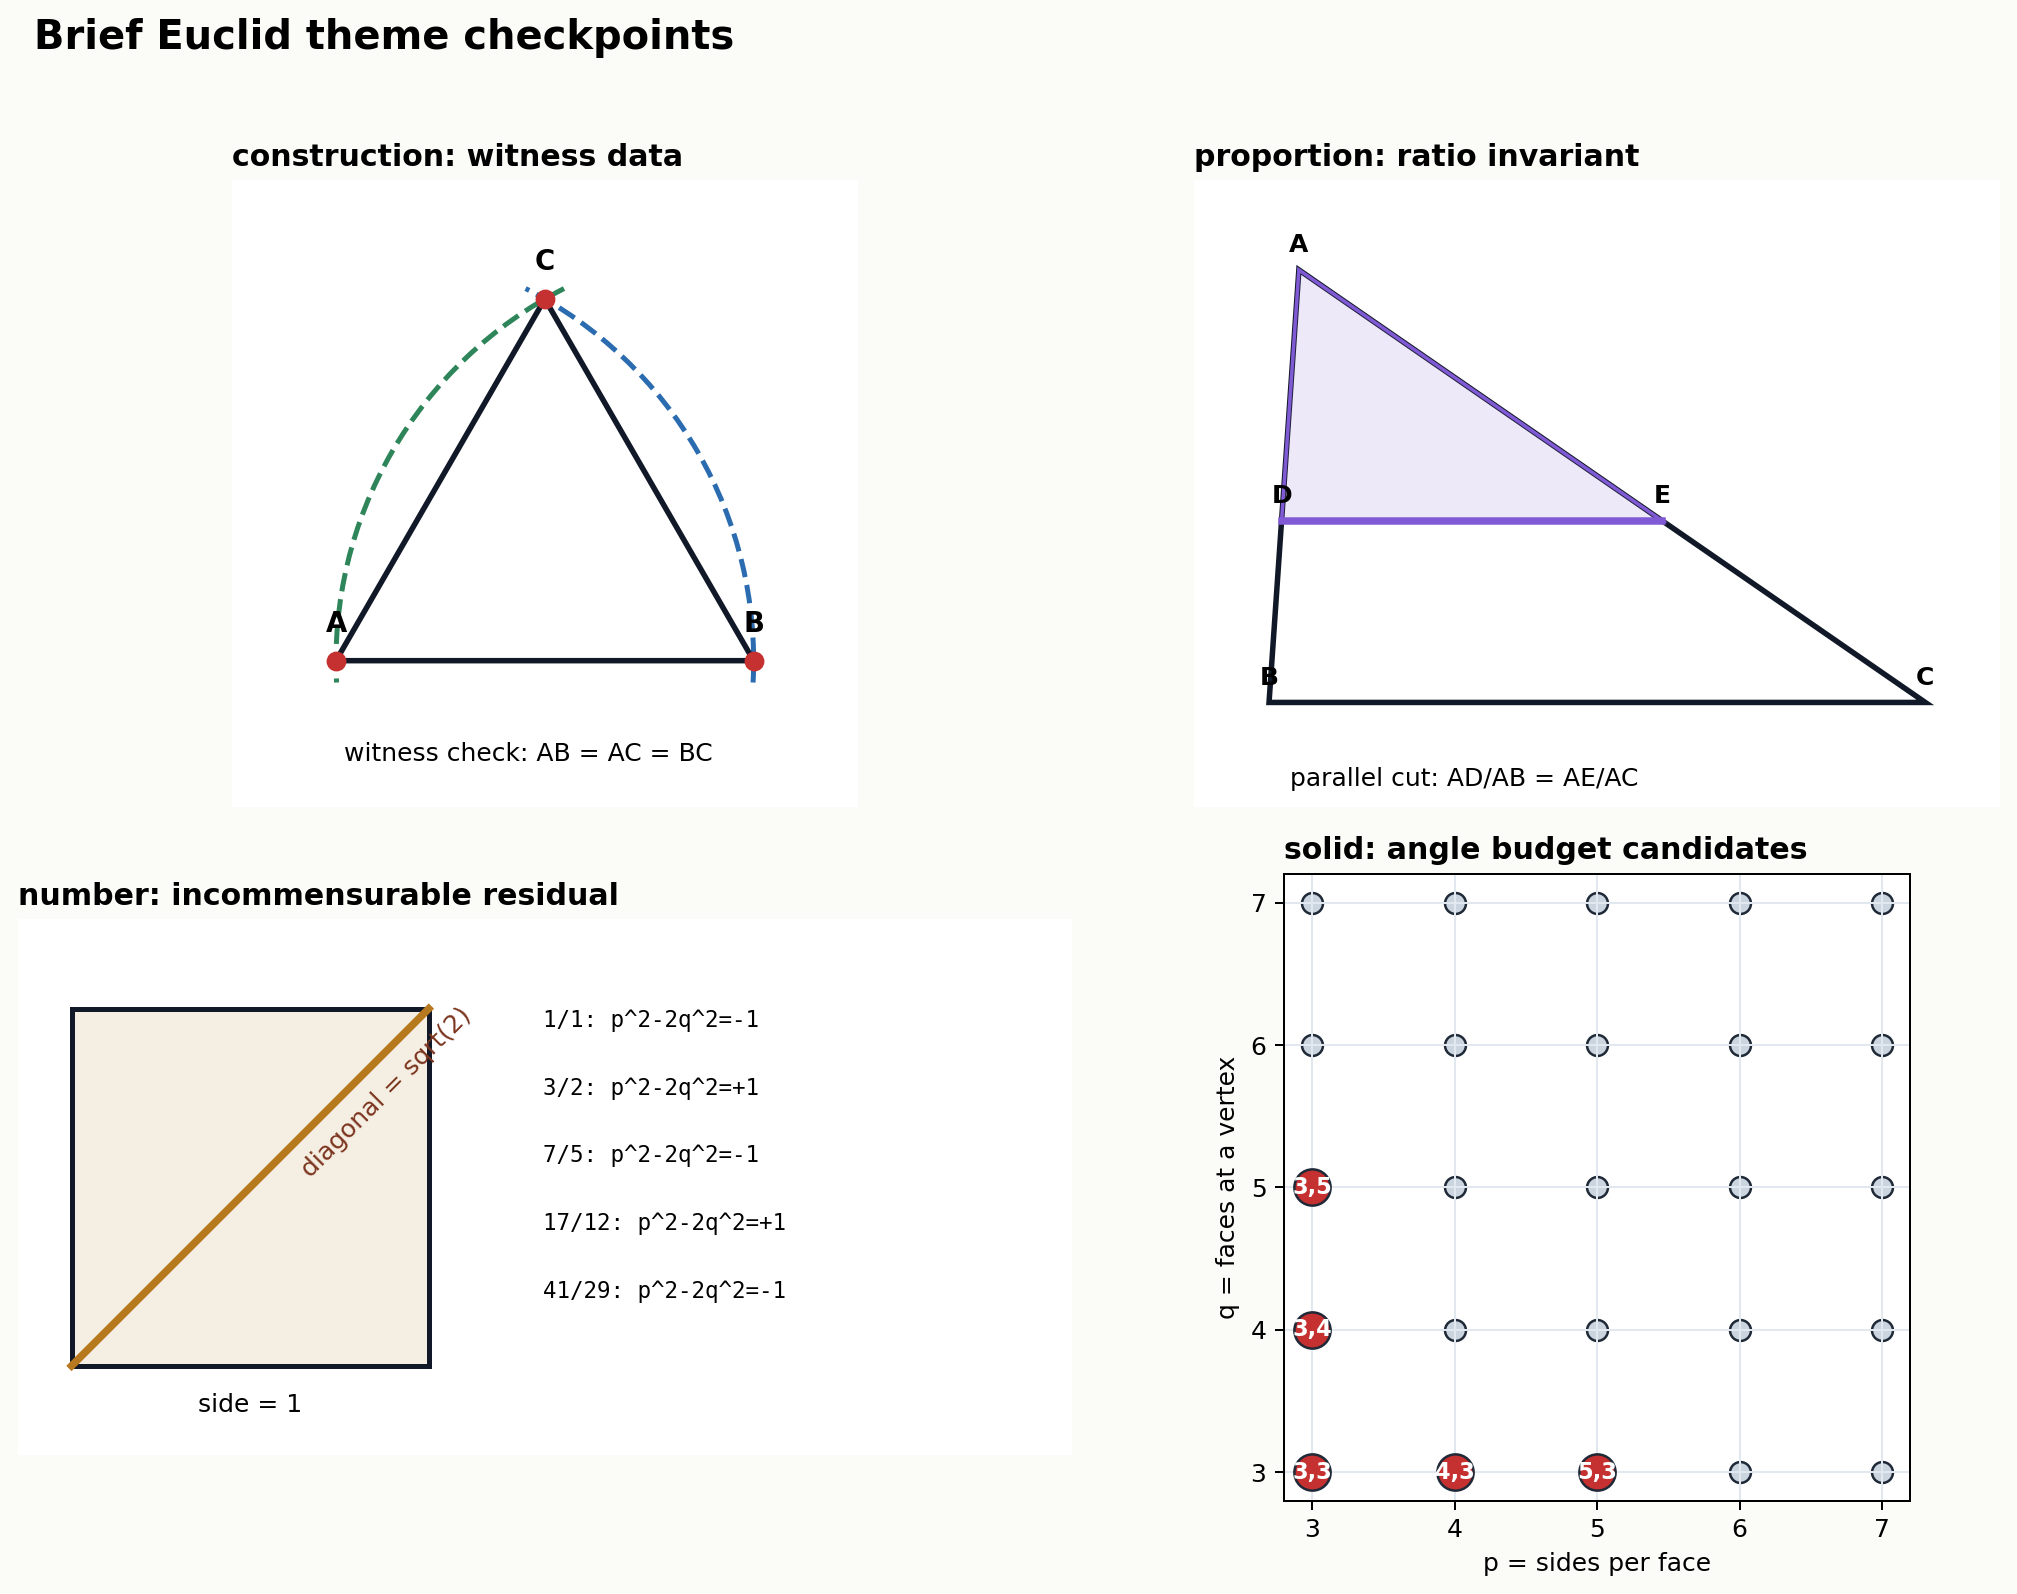

In [7]:
display_artifact(gallery_path, width=980)


## Proof And Invariant Scaffolds

The appendix gives references; this notebook turns representative references into small invariants. The point is not to prove Euclid again. The point is to know what kind of computational residue a later chapter should preserve when it invokes a Euclid tag.


In [8]:
a, b = sp.symbols("a b", positive=True)
book_ii_identity = sp.expand((a + b) ** 2 - (a**2 + 2 * a * b + b**2))
pythagorean_residue = 3**2 + 4**2 - 5**2
ratio_residue = sp.simplify((a / b) - ((3 * a) / (3 * b)))
mean_proportional_residue = sp.simplify((sp.sqrt(a * b) ** 2) - a * b)

platonic_counts = pd.DataFrame([
    {"solid": "tetrahedron", "p": 3, "q": 3, "V": 4, "E": 6, "F": 4},
    {"solid": "cube", "p": 4, "q": 3, "V": 8, "E": 12, "F": 6},
    {"solid": "octahedron", "p": 3, "q": 4, "V": 6, "E": 12, "F": 8},
    {"solid": "dodecahedron", "p": 5, "q": 3, "V": 20, "E": 30, "F": 12},
    {"solid": "icosahedron", "p": 3, "q": 5, "V": 12, "E": 30, "F": 20},
])
platonic_counts["Euler"] = platonic_counts["V"] - platonic_counts["E"] + platonic_counts["F"]
platonic_counts["angle_budget_less_than_2pi"] = platonic_counts.apply(lambda r: r["q"] * (r["p"] - 2) / r["p"] < 2, axis=1)
solid_counts_path = TABLES / "platonic-solid-count-checks.csv"
platonic_counts.to_csv(solid_counts_path, index=False)
record_artifact(solid_counts_path, "Platonic solid count checks table", min_bytes=128)

identity_checks = {
    "book_ii_square_expansion_residue": str(book_ii_identity),
    "pythagorean_3_4_5_residue": int(pythagorean_residue),
    "ratio_scaling_residue": str(ratio_residue),
    "mean_proportional_square_residue": str(mean_proportional_residue),
    "all_platonic_euler_two": bool(platonic_counts["Euler"].eq(2).all()),
    "all_platonic_angle_budgets_valid": bool(platonic_counts["angle_budget_less_than_2pi"].all()),
    "regular_solid_candidates_pq": theme_visual_checks["regular_solid_candidates_pq"],
}
assert book_ii_identity == 0
assert pythagorean_residue == 0
assert ratio_residue == 0
assert mean_proportional_residue == 0
assert identity_checks["all_platonic_euler_two"]
assert identity_checks["all_platonic_angle_budgets_valid"]
platonic_counts


,solid,p,q,V,E,F,Euler,angle_budget_less_than_2pi
0,tetrahedron,3,3,4,6,4,2,True
1,cube,4,3,8,12,6,2,True
2,octahedron,3,4,6,12,8,2,True
3,dodecahedron,5,3,20,30,12,2,True
4,icosahedron,3,5,12,30,20,2,True


## Applied Lab: Build A Checkpoint Route

Choose a target book and compute the prerequisite closure in the dependency map. The route is a practical reading tool: it tells you which Euclid themes a later course checkpoint is implicitly using. For example, a Book XIII regular-solid checkpoint pulls in plane constructions, ratios, arithmetic/incommensurability, and solid geometry.


In [9]:
def prerequisite_closure(graph, target):
    closure = nx.ancestors(graph, target) | {target}
    order = {book: i for i, book in enumerate(book_df["book"])}
    return sorted(closure, key=lambda book: order[book])

lab_targets = ["IV", "VI", "X", "XIII"]
lab_rows = []
for target in lab_targets:
    route = prerequisite_closure(G, target)
    route_df = book_df.set_index("book").loc[route]
    lab_rows.append({
        "target_book": target,
        "route_books": " -> ".join(route),
        "theme_set": ", ".join(sorted(route_df["primary_theme"].unique())),
        "source_selected_books": int(route_df["source_selected"].sum()),
        "appendix_silent_books": ", ".join(route_df.loc[~route_df["source_selected"]].index.tolist()) or "none",
        "course_checkpoint": book_df.set_index("book").loc[target, "course_checkpoint"],
    })
lab_df = pd.DataFrame(lab_rows)
lab_path = TABLES / "applied-lab-route.csv"
lab_df.to_csv(lab_path, index=False)
record_artifact(lab_path, "Applied lab prerequisite route table", min_bytes=256)

assert prerequisite_closure(G, "I") == ["I"]
assert "V" in prerequisite_closure(G, "XIII")
assert {"VII", "VIII", "IX"}.issubset(set(prerequisite_closure(G, "X")))
lab_df


,target_book,route_books,theme_set,source_selected_books,appendix_silent_books,course_checkpoint
0,IV,I -> III -> IV,"circle, construction, foundations",3,none,polygon construction and regular-pentagon tests
1,VI,I -> V -> VI,"foundations, proportion",3,none,"similarity, coordinates, and proportional-area..."
2,X,I -> V -> VI -> VII -> VIII -> IX -> X,"foundations, number, proportion",4,"VII, VIII, IX",constructibility obstructions and radical degr...
3,XIII,I -> III -> IV -> V -> VI -> VII -> VIII -> IX...,"circle, construction, foundations, number, pro...",9,"VII, VIII, IX",Platonic-solid classification and Euler/angle-...


## Final Sanity

The final check confirms that this is a direct appendix notebook with book-local artifacts. It verifies the graph shape, source-span metadata, symbolic identities, geometric residuals, and artifact paths/sizes.


In [10]:
source_span = "printed pp. 481-486; PDF pp. 493-498"
notebook_path = BOOK_ROOT / "appendix-brief-euclid" / "appendix-brief-euclid.ipynb"
forbidden = "build" + "_unit" + "_visuals"
notebook_text = notebook_path.read_text(encoding="utf-8")
assert forbidden not in notebook_text

visual_checks = {
    "unit": UNIT,
    "source_span": source_span,
    "book_graph": book_graph_checks,
    "theme_visual_checks": theme_visual_checks,
    "interactive_theme_flow_exists": flow_path.exists(),
    "roadmap_exists": roadmap_path.exists(),
    "gallery_exists": gallery_path.exists(),
}
visual_checks_path = save_json(visual_checks, UNIT, "checks", "visual-checks.json", root=ARTIFACT_ROOT)
record_artifact(visual_checks_path, "Visual checks summary", min_bytes=512)

artifact_checks = []
seen = set()
for record in artifact_records:
    path = BOOK_ROOT / record["path"]
    assert path.resolve().is_relative_to(UNIT_ARTIFACT_ROOT.resolve())
    assert path.relative_to(BOOK_ROOT).as_posix().startswith(f"artifacts/{UNIT}/")
    assert_artifact(path, min_bytes=128)
    seen.add(record["path"])
    artifact_checks.append({**record, "exists": True, "nonzero": path.stat().st_size > 0})

required_concepts = {
    "Book theme index table",
    "Books I-XIII dependency map",
    "Course checkpoint crosswalk table",
    "Interactive theme flow map",
    "Construction proportion number solid checkpoint gallery",
    "Platonic solid count checks table",
    "Applied lab prerequisite route table",
    "Visual checks summary",
}
assert required_concepts.issubset({record["concept"] for record in artifact_records})
assert set(book_df["book"]) == {roman(i) for i in range(1, 14)}
assert book_df["primary_theme"].notna().all()
assert book_df.groupby("primary_theme").size().sum() == 13
assert nx.is_directed_acyclic_graph(G)
assert nx.has_path(G, "I", "XIII")
assert len(theme_visual_checks["sqrt2_residuals"]) >= 5
assert all(item["p2_minus_2q2"] != 0 for item in theme_visual_checks["sqrt2_residuals"])

final_sanity = {
    "unit": UNIT,
    "source_span": source_span,
    "no_generic_visual_builder_reference": True,
    "graph_nodes": G.number_of_nodes(),
    "graph_edges": G.number_of_edges(),
    "source_selected_book_count": int(book_df["source_selected"].sum()),
    "appendix_silent_arithmetic_books": book_df.loc[~book_df["source_selected"], "book"].tolist(),
    "identity_checks": identity_checks,
    "lab_target_count": len(lab_df),
    "artifact_count_checked_before_final_json": len(seen),
    "artifact_paths_checked_before_final_json": sorted(seen),
}
final_sanity_path = save_json(final_sanity, UNIT, "checks", "final-sanity.json", root=ARTIFACT_ROOT)
record_artifact(final_sanity_path, "Final sanity summary", min_bytes=512)

notebook_sanity = {
    "unit": UNIT,
    "source_span": source_span,
    "artifact_count": len(artifact_records),
    "artifacts": artifact_records,
    "book_graph_checks": book_graph_checks,
    "identity_checks": identity_checks,
    "lab_targets": lab_targets,
    "all_paths_book_local": all(record["path"].startswith(f"artifacts/{UNIT}/") for record in artifact_records),
}
notebook_sanity_path = save_json(notebook_sanity, UNIT, "checks", "notebook-sanity.json", root=ARTIFACT_ROOT)
record_artifact(notebook_sanity_path, "Notebook sanity summary", min_bytes=512)

for record in artifact_records:
    assert_artifact(BOOK_ROOT / record["path"], min_bytes=128)

final_sanity


{'unit': 'appendix-brief-euclid',
 'source_span': 'printed pp. 481-486; PDF pp. 493-498',
 'no_generic_visual_builder_reference': True,
 'graph_nodes': 13,
 'graph_edges': 23,
 'source_selected_book_count': 10,
 'appendix_silent_arithmetic_books': ['VII', 'VIII', 'IX'],
 'identity_checks': {'book_ii_square_expansion_residue': '0',
  'pythagorean_3_4_5_residue': 0,
  'ratio_scaling_residue': '0',
  'mean_proportional_square_residue': '0',
  'all_platonic_euler_two': True,
  'all_platonic_angle_budgets_valid': True,
  'regular_solid_candidates_pq': [(3, 3), (3, 4), (3, 5), (4, 3), (5, 3)]},
 'lab_target_count': 4,
 'artifact_count_checked_before_final_json': 8,
 'artifact_paths_checked_before_final_json': ['artifacts/appendix-brief-euclid/checks/visual-checks.json',
  'artifacts/appendix-brief-euclid/figures/construction-gallery.png',
  'artifacts/appendix-brief-euclid/figures/euclid-book-roadmap.png',
  'artifacts/appendix-brief-euclid/interactive/euclid-theme-flow.html',
  'artifacts/a

## Takeaways

- The appendix is a reference instrument: each Euclid tag becomes a checkpoint that later notebooks can verify by construction data, symbolic residue, graph dependency, ratio equality, or mesh count.
- Books VII-IX are absent from the printed appendix list, but a whole-Elements map should still keep their arithmetic role visible because Book X depends on number-theoretic obstruction language.
- Construction, proportion, number, and solid geometry are not separate silos. The route to Book XIII runs through plane constructions, ratio theory, incommensurability, and solid vocabulary.
- Modernization does not mean replacing Euclid's proofs with code. It means making the reusable invariants explicit enough that the course can check when a later model preserves or breaks them.
